<a href="https://colab.research.google.com/github/PradipBanik/Build_2026/blob/main/Andrew_Karaoathy_summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
class nodes:
  def __init__(self, data, prev=(), op='', label=''):
    self._data = data
    self._prev = set(prev)
    self._op = op
    self._label = label
    self._grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    return f"{self._label}"

  def __add__(self, other):
    self.other = other if isinstance(other, nodes) else nodes(other, label=f"{other}")
    add_out = nodes(self._data + self.other._data, (self, self.other), '+')
    def _backward():
      self._grad += 1.0 * add_out._grad
      self.other._grad += 1.0 * add_out._grad
    add_out._backward = _backward
    return add_out

  def __radd__(self, other):
    return self + other

  def backward(self):
    topo=[]
    visited=[]
    def build_topo(v):
      if v not in visited:
        visited.append(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)
    self._grad = 1.0
    for node in reversed(topo):
      node._backward()


w1 = nodes(2, label='w1')
# w1 = nodes(2, label='w1')
# w2 = nodes(5, label='w2')
w2 = 5;# w2._label='w2'
c = w2+w1; c._label='c'
c._data

7

In [45]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    label_str = f"{n._label} | data {n._data:.4f} | grad {n._grad:.2e}"
    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

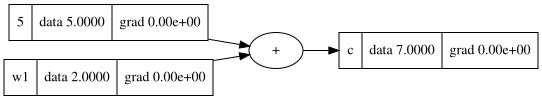

In [46]:
draw_dot(c)

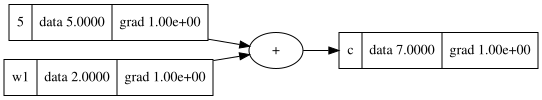

In [47]:
c.backward()
draw_dot(c)
